In [1]:
# Bloco 1 — Configuração: bibliotecas, caminhos (relativos à pasta do projeto) e verificação dos ficheiros
from pathlib import Path
import re
import unicodedata
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("future.no_silent_downcasting", True)

# Raiz do projeto = primeira pasta, a partir da do notebook e a subir, que contém data/processed
BASE = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "processed").is_dir()), None)
assert BASE is not None, "Pasta do projeto não encontrada: abrir o notebook dentro da pasta do projeto (a que contém data/processed)"
RAW = BASE / "data" / "raw"
PROCESSED = BASE / "data" / "processed"

FICHEIROS = {
    "cargo": "antaq_2025_cargo.xlsx",
    "cargo_ports": "antaq_2025_cargo_ports.xlsx",
    "port_calls": "antaq_2025_port_calls.xlsx",
    "stoppages": "antaq_2025_stoppages.xlsx",
    "panel": "antaq_2025_panel_gr23.xlsx",
}

PATH_TAB = PROCESSED / "tabela_completa.csv"                 # tabela de armadores — só leitura neste notebook
PATH_PRIO = PROCESSED / "imos_prioritarios.csv"              # lista prioritária fixa de 24/09/2026
PATH_BACKUP_262 = PROCESSED / "tabela_referencia_262.csv"    # estado pós-limpeza de 25/09/2026 (262 navios), usado no Bloco 15

em_falta = [str(RAW / f) for f in FICHEIROS.values() if not (RAW / f).exists()]
em_falta += [str(p) for p in (PATH_TAB, PATH_PRIO, PATH_BACKUP_262) if not p.exists()]
assert not em_falta, ("Ficheiros em falta:\n" + "\n".join(em_falta) +
                      "\n(Os ficheiros ANTAQ de data/raw descarregam-se do Estatístico Aquaviário da ANTAQ — ver README)")

print(f"Projeto: {BASE.name}")
print(f"{len(FICHEIROS)} ficheiros ANTAQ em data/raw")
print(f"Tabela de armadores: {PATH_TAB.name} | lista prioritária: {PATH_PRIO.name} | referência 262: {PATH_BACKUP_262.name}")

Projeto: ANTAQ_2025_Projeto2
5 ficheiros ANTAQ em data/raw
Tabela de armadores: tabela_completa.csv | lista prioritária: imos_prioritarios.csv | referência 262: tabela_referencia_262.csv


In [2]:
# Bloco 2 — Ingestão dos 5 ficheiros e renomeação das colunas para inglês
def norm_col(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower()
    s = s.replace(" - com movimentacao de carga", "")
    return re.sub(r"\s+", " ", s).strip()

COLS = {
    "ano": "year", "mes": "month", "complexo portuario": "port_complex",
    "instalacao de acostagem": "terminal", "navegacao da atracacao": "navigation",
    "tipo navegacao": "cargo_navigation", "id atracacao": "call_id",
    "imo da embarcacao": "imo", "numero de capitania": "capitania_no",
    "perfil da carga": "cargo_profile", "sentido": "direction",
    "tamanho do conteiner": "box_size", "tipo conteiner": "box_type",
    "estado conteiner": "box_status", "instalacao de origem": "origin_port",
    "instalacao de destino": "dest_port", "cidade origem": "origin_city",
    "cidade destino": "dest_city", "pais origem": "origin_country",
    "pais destino": "dest_country",
    "total de movimentacao portuaria em toneladas (t)": "tonnes",
    "total de movimentacao conteineres (bruto) (teu) twenty feet equivalent unit": "teu",
    "total de movimentacao conteineres (liquido) em toneladas (t)": "net_tonnes",
    "total de atracacoes": "n_calls", "tipos de paralisacao": "stoppage_type",
    "consignacao media em t/navio.": "avg_consignment_t",
    "tempo medio para atracacao em horas": "t_wait_h",
    "tempo medio para inicio da operacao em horas": "t_to_ops_h",
    "tempo medio de operacao em horas": "t_ops_h",
    "tempo medio para desatracacao em horas": "t_to_unberth_h",
    "tempo medio atracado em horas": "t_berth_h",
    "tempo medio de estadia em horas": "t_stay_h",
    "tempo de paralisacao (em horas)": "t_stoppage_h",
    "instalacao portuaria": "facility", "peso carga bruta": "teu_gr23",
    "distribuicao percentual": "share_pct", "crescimento/reducao": "growth",
}

dfs = {}
for nome, ficheiro in FICHEIROS.items():
    df = pd.read_excel(RAW / ficheiro, engine="calamine")
    df.columns = [norm_col(c) for c in df.columns]
    sem_mapa = [c for c in df.columns if c not in COLS]
    assert not sem_mapa, f"{nome}: colunas sem mapeamento {sem_mapa}"
    dfs[nome] = df.rename(columns=COLS)

for nome, df in dfs.items():
    ids = df["call_id"].nunique() if "call_id" in df.columns else "—"
    print(f"{nome}: {len(df):,} linhas | {df.shape[1]} colunas | call_id únicos: {ids}")

cargo: 243,855 linhas | 20 colunas | call_id únicos: 10007
cargo_ports: 322,159 linhas | 18 colunas | call_id únicos: 10007
port_calls: 89,663 linhas | 20 colunas | call_id únicos: 10007
stoppages: 59,022 linhas | 18 colunas | call_id únicos: 2037
panel: 22 linhas | 4 colunas | call_id únicos: —


In [3]:
# Bloco 3 — Limpeza: tirar "Totais", converter tempos e construir 1 linha por escala
MESES = {"jan": 1, "fev": 2, "mar": 3, "abr": 4, "mai": 5, "jun": 6,
         "jul": 7, "ago": 8, "set": 9, "out": 10, "nov": 11, "dez": 12}
TEMPOS = ["t_wait_h", "t_to_ops_h", "t_ops_h", "t_to_unberth_h", "t_berth_h", "t_stay_h"]
FLAGS = [f"{c}_discrepant" for c in TEMPOS]

def remover_totais(df, col):
    mask = df[col].astype(str).str.strip().eq("Totais")
    assert mask.sum() == 1, f"Esperada 1 linha 'Totais' em {col}, encontradas {mask.sum()}"
    return df.loc[~mask].copy()

def limpar_tempos(df):
    for c in TEMPOS:
        df[f"{c}_discrepant"] = df[c].astype(str).str.strip().eq("Valor Discrepante")
        df[c] = pd.to_numeric(df[c].replace({"-": np.nan, "Valor Discrepante": np.nan}), errors="raise")
    return df

cargo = dfs["cargo"].copy()
assert cargo["month"].isin(MESES.keys()).all(), "Mês fora do mapa na Carga"
cargo["month"] = cargo["month"].map(MESES)

calls = remover_totais(dfs["port_calls"], "year")
calls["year"] = calls["year"].astype(int)
calls["month"] = calls["month"].astype(int)
calls["call_id"] = calls["call_id"].astype("int64")
calls = limpar_tempos(calls)

stops = remover_totais(dfs["stoppages"], "call_id")
stops["call_id"] = stops["call_id"].astype("int64")
stops = limpar_tempos(stops)
stops["avg_consignment_t"] = pd.to_numeric(stops["avg_consignment_t"].replace("-", np.nan), errors="raise")

panel = dfs["panel"].copy()
panel["growth"] = pd.to_numeric(panel["growth"].replace("-", np.nan), errors="raise")

assert calls["month"].between(1, 12).all() and cargo["month"].between(1, 12).all()
g = calls.groupby("call_id")
var_num = g[TEMPOS + ["t_stoppage_h"]].nunique(dropna=True).max()
assert (var_num <= 1).all(), f"Valores numéricos diferentes dentro da mesma escala:\n{var_num}"
var_dim = g[["month", "terminal", "navigation"]].nunique(dropna=False).max()
assert (var_dim <= 1).all(), f"Mês/terminal/navegação variam dentro da escala:\n{var_dim}"

ids_cargo, ids_calls, ids_stops = set(cargo["call_id"]), set(calls["call_id"]), set(stops["call_id"])
assert ids_cargo == ids_calls, f"Carga vs Escalas: {len(ids_cargo ^ ids_calls)} IDs sem par"

orfaos = ids_stops - ids_calls
if orfaos:
    print(f"Paralisações sem escala correspondente: {len(orfaos)} ID(s), excluídos")
assert len(orfaos) <= 5, f"{len(orfaos)} IDs de paralisação sem escala — demasiados para ignorar"
stops = stops[~stops["call_id"].isin(orfaos)].copy()
ids_stops = set(stops["call_id"])

esc = g.agg(
    year=("year", "first"), month=("month", "first"), terminal=("terminal", "first"),
    navigation=("navigation", "first"), imo=("imo", "first"),
    teu=("teu", "sum"), tonnes=("tonnes", "sum"), t_stoppage_h=("t_stoppage_h", "first"),
    **{c: (c, "first") for c in TEMPOS},
    **{f: (f, "any") for f in FLAGS},
).reset_index()
for c in TEMPOS:
    esc.loc[esc[f"{c}_discrepant"], c] = np.nan
assert esc["call_id"].is_unique and len(esc) == len(ids_calls)

esc_lc = esc[esc["navigation"] == "Longo Curso"]
disc = esc_lc[FLAGS].sum().astype(int)
disc.index = TEMPOS
print(f"Escalas: {len(esc):,} | Longo Curso: {len(esc_lc):,} | Paralisações: {len(ids_stops):,} IDs")
print("Escalas LC com 'Valor Discrepante' (tempo excluído pela ANTAQ):")
print(disc.to_frame("n").assign(pct=lambda d: (d["n"] / len(esc_lc) * 100).round(2)).to_string())

Paralisações sem escala correspondente: 1 ID(s), excluídos
Escalas: 10,007 | Longo Curso: 6,580 | Paralisações: 2,035 IDs
Escalas LC com 'Valor Discrepante' (tempo excluído pela ANTAQ):
                 n   pct
t_wait_h        70  1.06
t_to_ops_h      21  0.32
t_ops_h         58  0.88
t_to_unberth_h  33  0.50
t_berth_h       39  0.59
t_stay_h        69  1.05


In [4]:
# Bloco 4 — Validação do TEU Longo Curso contra as referências e entre ficheiros
REF = {"lc": 11_085_805.9, "br_br": 1_532_094, "intl": 9_553_712}

lc_cargo = cargo[cargo["navigation"] == "Longo Curso"]
br_br = (lc_cargo["origin_country"] == "Brasil") & (lc_cargo["dest_country"] == "Brasil")
teu_lc = lc_cargo["teu"].sum()
teu_brbr = lc_cargo.loc[br_br, "teu"].sum()
teu_intl = teu_lc - teu_brbr

print(f"TEU LC:        {teu_lc:,.1f}  (ref {REF['lc']:,.1f})")
print(f"Brasil→Brasil: {teu_brbr:,.1f}  (ref {REF['br_br']:,})")
print(f"Internacional: {teu_intl:,.1f}  (ref {REF['intl']:,})")
assert abs(teu_lc - REF["lc"]) < 1
assert abs(teu_brbr - REF["br_br"]) < 1
assert abs(teu_intl - REF["intl"]) < 1

nav = pd.concat({
    "cargo": cargo.drop_duplicates("call_id").set_index("call_id")["navigation"],
    "calls": esc.set_index("call_id")["navigation"],
}, axis=1)
assert (nav["cargo"] == nav["calls"]).all(), "Navegação diferente entre Carga e Escalas"

comp = pd.concat({
    "cargo": lc_cargo.groupby("call_id")["teu"].sum(),
    "calls": esc_lc.set_index("call_id")["teu"],
}, axis=1).fillna(0)
assert ((comp["cargo"] - comp["calls"]).abs() <= 0.5).all(), "TEU por escala diferente entre ficheiros"
print(f"\nCarga e Escalas coincidem escala a escala ({len(comp):,} escalas LC)")

TEU LC:        11,085,805.9  (ref 11,085,805.9)
Brasil→Brasil: 1,532,094.1  (ref 1,532,094)
Internacional: 9,553,711.8  (ref 9,553,712)

Carga e Escalas coincidem escala a escala (6,580 escalas LC)


In [5]:
# Bloco 5 — Validação do cargo_ports e reconciliação com o painel GR2.3
ports = dfs["cargo_ports"].copy()
assert ports["month"].isin(MESES.keys()).all(), "Mês fora do mapa em cargo_ports"
ports["month"] = ports["month"].map(MESES)
ports["call_id"] = ports["call_id"].astype("int64")

assert set(ports["call_id"]) == ids_calls, "cargo_ports com IDs diferentes das Escalas"
assert abs(ports["teu"].sum() - cargo["teu"].sum()) < 1, "TEU total diferente da Carga"

ports = ports.merge(esc[["call_id", "navigation"]], on="call_id", how="left")
br_br_p = (ports["origin_country"] == "Brasil") & (ports["dest_country"] == "Brasil")
teu_lc_escala = ports.loc[ports["navigation"] == "Longo Curso", "teu"].sum()
teu_intl_carga = ports.loc[~br_br_p, "teu"].sum()
teu_painel = panel["teu_gr23"].sum()
dif_painel = (teu_painel / teu_intl_carga - 1) * 100

print(f"TEU em escalas de Longo Curso (navegação da escala): {teu_lc_escala:,.1f}")
print(f"TEU internacional (navegação da carga):             {teu_intl_carga:,.1f}")
print(f"Painel GR2.3:                                        {teu_painel:,.0f}  ({dif_painel:+.2f}%)")
assert abs(teu_lc_escala - REF["lc"]) < 1, "TEU por navegação da escala não bate"
assert abs(teu_intl_carga - 10_314_405) < 1, "TEU internacional não bate com a reconciliação"
assert abs(dif_painel) < 1, "Painel GR2.3 afasta-se >1% — unidade ou universo diferente"
print(f"Linhas sem porto de origem/destino: {ports['origin_port'].isna().sum()}")

TEU em escalas de Longo Curso (navegação da escala): 11,085,805.9
TEU internacional (navegação da carga):             10,314,404.9
Painel GR2.3:                                        10,298,892  (-0.15%)
Linhas sem porto de origem/destino: 97


In [6]:
# Bloco 6 — Paralisações: 1 linha por escala+causa e teste de aditividade
TOL = 0.05

var = stops.groupby(["call_id", "stoppage_type"])["t_stoppage_h"].nunique(dropna=True).max()
assert var <= 1, "Tempo de paralisação varia dentro da mesma escala+causa"

par = (stops.drop_duplicates(["call_id", "stoppage_type"])[["call_id", "stoppage_type", "t_stoppage_h"]]
       .merge(esc[["call_id", "navigation", "terminal", "month"]], on="call_id", how="left"))
assert par["navigation"].notna().all()

soma = par.groupby("call_id")["t_stoppage_h"].sum()
chk = esc.set_index("call_id")["t_stoppage_h"].to_frame().join(soma.rename("soma"), how="left").fillna(0)
assert (chk["t_stoppage_h"] - chk["soma"]).abs().max() <= TOL, "Soma por causa ≠ total da escala"
print(f"Paralisações validadas: {par['stoppage_type'].nunique()} causas | {len(par):,} pares escala+causa")

Paralisações validadas: 27 causas | 5,867 pares escala+causa


In [7]:
# Bloco 7 — Tempos de Longo Curso: função de resumo, visão geral e cálculo por terminal
N_MIN = 100

def resumo(d):
    w, o = d["t_wait_h"].dropna(), d["t_ops_h"].dropna()
    return pd.Series({
        "escalas": len(d), "teu_mil": d["teu"].sum() / 1e3,
        "espera_p50": w.median(), "espera_p90": w.quantile(0.9),
        "pct_espera_lt1h": (w < 1).mean() * 100,
        "pct_discrepante": d["t_wait_h_discrepant"].mean() * 100,
        "operacao_p50": o.median(), "operacao_p90": o.quantile(0.9),
    })

cols = ["t_wait_h", "t_ops_h", "t_wait_h_discrepant", "teu"]
print("Longo Curso — todas as escalas (h)")
print(resumo(esc_lc[cols]).round(1).to_string())
term = esc_lc.groupby("terminal")[cols].apply(resumo)

Longo Curso — todas as escalas (h)
escalas             6580.0
teu_mil            11085.8
espera_p50             8.0
espera_p90            59.5
pct_espera_lt1h       11.8
pct_discrepante        1.1
operacao_p50          16.2
operacao_p90          33.2


In [8]:
# Bloco 8 — Filtros de comparabilidade, ranking de terminais e base comparável
MAX_PCT_LT1H = 50
MIN_RAZAO_P90_P50 = 2
MIN_TEU_ESCALA = 300

prod = (esc_lc.assign(teu_h=esc_lc["teu"] / esc_lc["t_berth_h"].where(esc_lc["t_berth_h"] > 0))
        .groupby("terminal")["teu_h"].median().rename("teu_por_hora_atracado"))

term = term.drop(columns=["teu_por_hora_atracado"], errors="ignore").join(prod).assign(
    teu_por_escala=lambda d: d["teu_mil"] * 1e3 / d["escalas"],
    razao_p90_p50=lambda d: d["espera_p90"] / d["espera_p50"],
)
term["motivo_exclusao"] = np.select(
    [term["escalas"] < N_MIN,
     term["teu_por_escala"] < MIN_TEU_ESCALA,
     (term["pct_espera_lt1h"] > MAX_PCT_LT1H) | (term["razao_p90_p50"] < MIN_RAZAO_P90_P50)],
    [f"<{N_MIN} escalas", "não-contentores", "registo de chegada"], default="",
)

final = term[term["motivo_exclusao"] == ""].sort_values("espera_p50")
excl = term[(term["motivo_exclusao"] != "") & (term["escalas"] >= N_MIN)]
cols_final = ["escalas", "teu_por_escala", "espera_p50", "espera_p90", "pct_discrepante",
              "operacao_p50", "teu_por_hora_atracado"]

print(f"Ranking final: {len(final)} terminais | {final['escalas'].sum() / len(esc_lc) * 100:.1f}% das escalas LC "
      f"| {final['teu_mil'].sum() / esc_lc['teu'].sum() * 1e5:.1f}% do TEU LC")
print(final[cols_final].round(1).to_string())
print("\nExcluídos (≥100 escalas):")
print(excl[["escalas", "teu_por_escala", "pct_espera_lt1h", "razao_p90_p50", "motivo_exclusao"]].round(1).to_string())

base = esc_lc[esc_lc["terminal"].isin(final.index)]
print("\nLongo Curso — base comparável (h)")
print(resumo(base[cols]).round(1).to_string())

Ranking final: 11 terminais | 72.9% das escalas LC | 84.2% do TEU LC
                                                     escalas  teu_por_escala  espera_p50  espera_p90  pct_discrepante  operacao_p50  teu_por_hora_atracado
terminal                                                                                                                                                  
Salvador | Tecon Área 2                                150.0          1176.0         2.0        29.0              0.0          13.7                   60.6
Itajaí | Cais Arrendado Transitoriamente               246.0          1097.5         6.6        40.8              0.4          13.2                   50.6
Porto Itapoá Terminais Portuários                      692.0          2090.3         8.3        44.5              6.4          13.8                   84.6
Terminal Portuário do Pecém                            184.0          1015.1        10.8        52.9              0.5           9.8                   68.2
R

In [9]:
# Bloco 9 — Decomposição do tempo por fase (medianas, base comparável)
FASES = ["t_wait_h", "t_to_ops_h", "t_ops_h", "t_to_unberth_h", "t_berth_h", "t_stay_h"]

b = base.copy()
residuo = b["t_berth_h"] - (b["t_to_ops_h"] + b["t_ops_h"] + b["t_to_unberth_h"])
assert residuo.abs().max(skipna=True) < 0.1, "Fases no cais não somam ao tempo atracado"
b["cais_sem_operar_h"] = b["t_berth_h"] - b["t_ops_h"]

dec = b.groupby("terminal")[FASES + ["cais_sem_operar_h"]].median().loc[final.index]
dec.columns = ["espera", "ate_inicio_op", "operacao", "ate_desatracar", "atracado", "estadia", "cais_sem_operar"]
print("Medianas por fase (h) — base comparável")
print(dec.round(1).to_string())

Medianas por fase (h) — base comparável
                                                     espera  ate_inicio_op  operacao  ate_desatracar  atracado  estadia  cais_sem_operar
terminal                                                                                                                                
Salvador | Tecon Área 2                                 2.0            1.4      13.7             1.2      16.8     23.4              2.7
Itajaí | Cais Arrendado Transitoriamente                6.6            1.3      13.2             2.8      19.6     31.0              4.8
Porto Itapoá Terminais Portuários                       8.3            1.8      13.8             2.7      20.0     30.7              5.1
Terminal Portuário do Pecém                            10.8            0.7       9.8             0.6      11.6     24.8              1.5
Rio Grande | Cais Tecon Rio Grande S.A.                14.0            0.5      18.8             1.1      20.8     37.8              1.6
D

In [10]:
# Bloco 10 — Espera: mediana e intervalo de confiança 95% por bootstrap
rng = np.random.default_rng(42)
N_BOOT = 2000

def ic_mediana(s):
    s = s.dropna().to_numpy()
    meds = np.median(rng.choice(s, size=(N_BOOT, len(s)), replace=True), axis=1)
    return pd.Series({"p50": np.median(s), "ic_inf": np.percentile(meds, 2.5), "ic_sup": np.percentile(meds, 97.5)})

ic = base.groupby("terminal")["t_wait_h"].apply(ic_mediana).unstack().loc[final.index]
ic["amplitude"] = ic["ic_sup"] - ic["ic_inf"]
print("Espera — mediana e IC 95% bootstrap (h)")
print(ic.round(1).to_string())

Espera — mediana e IC 95% bootstrap (h)
                                                      p50  ic_inf  ic_sup  amplitude
terminal                                                                            
Salvador | Tecon Área 2                               2.0     1.8     2.2        0.3
Itajaí | Cais Arrendado Transitoriamente              6.6     5.1     9.6        4.5
Porto Itapoá Terminais Portuários                     8.3     6.6     9.9        3.3
Terminal Portuário do Pecém                          10.8     7.5    15.0        7.5
Rio Grande | Cais Tecon Rio Grande S.A.              14.0    11.5    18.5        7.0
DP World Santos                                      15.5    13.3    17.7        4.4
Santos | Cais Da Santos Brasil (Ssz 16) - Privativo  15.6    13.6    18.2        4.7
Santos | Cais Da Btp (Ssz 41) - Privativo            19.0    15.9    22.7        6.8
Paranaguá | Cais Público                             19.5    16.3    23.6        7.2
Paranaguá | Tcp          

In [11]:
# Bloco 11 — Padrão de registo de paralisações nos terminais do ranking (LC)
cob = (esc_lc[esc_lc["terminal"].isin(final.index)]
       .groupby("terminal")
       .agg(escalas=("call_id", "size"),
            pct_com_paralisacao=("t_stoppage_h", lambda s: (s > 0).mean() * 100),
            horas_por_escala=("t_stoppage_h", "mean")))
n_causas = par[par["navigation"] == "Longo Curso"].groupby("terminal")["stoppage_type"].nunique()
cob["causas_usadas"] = n_causas.reindex(cob.index).fillna(0).astype(int)
print("Padrão de registo de paralisações — terminais do ranking (LC)")
print(cob.sort_values("pct_com_paralisacao", ascending=False).round(2).to_string())

Padrão de registo de paralisações — terminais do ranking (LC)
                                                     escalas  pct_com_paralisacao  horas_por_escala  causas_usadas
terminal                                                                                                          
Itajaí | Cais Arrendado Transitoriamente                 246                98.78              6.23             21
Paranaguá | Tcp                                          647                98.45              3.51              6
Paranaguá | Cais Público                                 285                96.49              4.41              6
Porto Itapoá Terminais Portuários                        692                12.72              0.44              1
DP World Santos                                          452                 0.00              0.00              0
Portonave - Terminais Portuários de Navegantes           334                 0.00              0.00              0
Rio Grande | Cais 

In [12]:
# Bloco 12 — Cobertura da tabela de armadores (só leitura; não grava nada)
lc_imo = cargo[cargo["navigation"] == "Longo Curso"].copy()
lc_imo["imo"] = pd.to_numeric(lc_imo["imo"], errors="coerce")
teu_sem_imo = lc_imo.loc[lc_imo["imo"].isna(), "teu"].sum()
lc_imo = lc_imo.dropna(subset=["imo"]).astype({"imo": "int64"})

teu_imo = lc_imo.groupby("imo")["teu"].sum().sort_values(ascending=False)
teu_imo = teu_imo[teu_imo > 0]
total = teu_imo.sum()
acum = teu_imo.cumsum() / total

tab = pd.read_csv(PATH_TAB)
mapeados = set(pd.to_numeric(tab["IMO"], errors="coerce").dropna().astype("int64"))
teu_map = teu_imo[teu_imo.index.isin(mapeados)].sum()

print(f"TEU LC sem IMO: {teu_sem_imo:,.1f}")
print(f"IMOs LC com TEU > 0: {len(teu_imo)}")
for p in [0.5, 0.8, 0.9, 0.95]:
    print(f"  {p:.0%} do TEU LC: {(acum < p).sum() + 1} navios")
print(f"Tabela de armadores: {len(tab)} navios | {len(mapeados & set(teu_imo.index))} com TEU LC "
      f"| cobrem {teu_map / total:.1%} do TEU LC")

prio = pd.read_csv(PATH_PRIO)
prio.insert(0, "n", range(1, len(prio) + 1))
prio["na_tabela"] = prio["imo"].isin(mapeados)
pend = prio.loc[~prio["na_tabela"], ["n", "imo", "teu_lc"]].copy()
pend["cobertura_acum_pct"] = ((teu_map + pend["teu_lc"].cumsum()) / total * 100).round(1)
print(f"\nLista prioritária: {prio['na_tabela'].sum()} de {len(prio)} já na tabela | por pesquisar: {len(pend)}")
print(pend.to_string(index=False))

TEU LC sem IMO: 404.0
IMOs LC com TEU > 0: 675
  50% do TEU LC: 95 navios
  80% do TEU LC: 219 navios
  90% do TEU LC: 297 navios
  95% do TEU LC: 354 navios
Tabela de armadores: 324 navios | 324 com TEU LC | cobrem 90.5% do TEU LC

Lista prioritária: 56 de 58 já na tabela | por pesquisar: 2
 n     imo   teu_lc  cobertura_acum_pct
36 9718947 24079.75                90.8
50 9976460 20374.25                90.9


In [13]:
# Bloco 13 — Normalização de operadores (marca) e agregação por grupo (só definições)
NORM_OPS = {
    "CMA-CGM": "CMA CGM", "CMA CGM (Mercosul Line)": "CMA CGM", "Mercosul": "CMA CGM",
    "Mercosul Line": "CMA CGM", "Hyundai": "HMM", "Hyundai (HMM)": "HMM",
    "COSCO SHIPPING Lines": "COSCO", "NYK Line": "ONE Line", "Aliança (ANRM)": "Maersk",
}
SPLIT_OPS = {"ONE Line/Hapag-Lloyd (serviço RBM)": ["ONE Line", "Hapag-Lloyd"]}
REMOVER_OPS = {"Seaspan Corporation"}
GRUPO_OPS = {"Log-In": "MSC", "CNC Line": "CMA CGM", "Gold Star Line": "ZIM", "OOCL": "COSCO"}

GRUPO_TITULAR = [
    (r"\bnyk\b|mitsui o\.?\s?s\.?\s?k|\bmol\b|\bk[\s-]?line\b|kawasaki kisen|ocean network express|^one\b", "ONE Line"),
    (r"alian[cç]a|hamburg s[uü]d|maersk", "Maersk"),
    (r"log-?in", "MSC"),
    (r"mercosul|^cma[\s-]?cgm", "CMA CGM"),
    (r"^cosco", "COSCO"),
    (r"hapag", "Hapag-Lloyd"),
    (r"^msc\b|mediterranean shipping", "MSC"),
    (r"^hmm\b|hyundai merchant", "HMM"),
    (r"^evergreen", "Evergreen"),
    (r"yang ming", "Yang Ming"),
    (r"^zim\b", "ZIM"),
    (r"^pil\b|pacific international lines", "PIL"),
    (r"^oocl\b|orient overseas", "OOCL"),
]
MARCAS = [("MSC ", "MSC"), ("MAERSK ", "Maersk"), ("CMA CGM ", "CMA CGM"), ("COSCO ", "COSCO"),
          ("ONE ", "ONE Line"), ("EVER ", "Evergreen"), ("HMM ", "HMM"), ("YM ", "Yang Ming"),
          ("ZIM ", "ZIM"), ("OOCL ", "OOCL"), ("KOTA ", "PIL")]

def ops_lista(s):
    """Operadores ao nível da marca, normalizados e sem repetições."""
    if pd.isna(s) or str(s).strip() == "":
        return []
    out = []
    for x in [p.strip() for p in str(s).split(",")]:
        for y in SPLIT_OPS.get(x, [x]):
            y = NORM_OPS.get(y, y)
            if y and y not in REMOVER_OPS and y not in out:
                out.append(y)
    return out

def ops_grupo(s):
    """Operadores ao nível do grupo, sem repetições (COSCO + OOCL conta uma vez)."""
    out = []
    for o in ops_lista(s):
        g = GRUPO_OPS.get(o, o)
        if g not in out:
            out.append(g)
    return out

def grupo_titular(t):
    if pd.isna(t):
        return t
    for pat, g in GRUPO_TITULAR:
        if re.search(pat, str(t).strip(), flags=re.I):
            return g
    return str(t).strip()

def marca_nome(nome, ops):
    n = str(nome).upper().strip() + " "
    for pref, m in MARCAS:
        if n.startswith(pref) and m in ops:
            return m
    if n.strip().endswith(" EXPRESS") and "Hapag-Lloyd" in ops:
        return "Hapag-Lloyd"
    return None

marcas = sorted({o for s in tab["Operadores_Confirmados"] for o in ops_lista(s)})
grupos = sorted({o for s in tab["Operadores_Confirmados"] for o in ops_grupo(s)})
print(f"{len(marcas)} marcas → {len(grupos)} grupos")
print(", ".join(grupos))

30 marcas → 26 grupos
Borchard, CMA CGM, COSCO, CU Lines, Emirates, Evergreen, GOSU, HMM, Hapag-Lloyd, KMTC, Laurel Navigation, MSC, Maersk, Marfret, ONE Line, PIL, QT Lihui Ltd, RCL, SITC, Turkon, UFEE (não identificado), WEC Lines, Wan Hai Lines, X-Press, Yang Ming, ZIM


In [14]:
# Bloco 14 — Titularidade: verificada vs por defeito (só leitura)
t = tab.copy()
t["IMO"] = pd.to_numeric(t["IMO"], errors="coerce").astype("int64")
t["teu_lc"] = t["IMO"].map(teu_imo).fillna(0)
t["Estrutura_Verificada"] = t["Estrutura_Titularidade"].where(t["Titularidade_Confirmada"] == True, "Não verificada")

res = t.groupby("Estrutura_Verificada").agg(navios=("IMO", "size"), teu_lc=("teu_lc", "sum"))
res["pct_teu_lc"] = (res["teu_lc"] / total * 100).round(1)
print(res.sort_values("teu_lc", ascending=False).to_string())
print("\nEstrutura gravada × titularidade confirmada:")
print(pd.crosstab(t["Estrutura_Titularidade"], t["Titularidade_Confirmada"]).to_string())

                      navios      teu_lc  pct_teu_lc
Estrutura_Verificada                                
Não verificada           143  6049935.25        54.6
Propria                  102  2249137.75        20.3
Afretada                  79  1738173.25        15.7

Estrutura gravada × titularidade confirmada:
Titularidade_Confirmada  False  True 
Estrutura_Titularidade               
Afretada                     0     79
Afretada Provisoria          2      0
Propria                    141    102


In [15]:
# Bloco 15 — TEU por grupo operador: intervalo entre duas regras e estabilidade face ao estado de 262 navios (só leitura)
def grupo_armador(x):
    x = NORM_OPS.get(x, x)
    return GRUPO_OPS.get(x, x)

def teu_por_grupo(tabela):
    t = tabela.copy()
    t["IMO"] = pd.to_numeric(t["IMO"], errors="coerce").astype("int64")
    t["teu_lc"] = t["IMO"].map(teu_imo).fillna(0)
    # Regra 1: TEU inteiro para o grupo do Armador_Operador (inclui "Múltiplos")
    r1 = t.assign(g=t["Armador_Operador"].map(grupo_armador)).groupby("g")["teu_lc"].sum()
    # Regra 2: TEU dividido por igual entre os grupos que operam o navio
    t["grupos"] = t["Operadores_Confirmados"].apply(ops_grupo)
    assert (t["grupos"].str.len() > 0).all(), "Há navios sem operadores"
    t["teu_split"] = t["teu_lc"] / t["grupos"].str.len()
    r2 = t.explode("grupos").groupby("grupos")["teu_split"].sum()
    return pd.concat([r1.rename("inteiro"), r2.rename("dividido")], axis=1).fillna(0) / total * 100

antes = pd.read_csv(PATH_BACKUP_262)
assert len(antes) == 262 and (antes["Estrutura_Titularidade"] == "Propria").sum() == 200, \
    "O backup não é o estado pós-limpeza (262 navios, 200 Propria)"

n_ant, n_at = len(antes), len(tab)
r_ant, r_at = teu_por_grupo(antes), teu_por_grupo(tab)
q_ant, q_at = r_ant / r_ant.sum() * 100, r_at / r_at.sum() * 100   # quota dentro do TEU mapeado
col_delta = f"Δ mapeado vs {n_ant} (pp)"

pub = pd.concat({
    "% TEU LC (mín.)": r_at,
    "% TEU mapeado": q_at,
    col_delta: q_at.sub(q_ant, fill_value=0),
}, axis=1).fillna(0).sort_values(("% TEU LC (mín.)", "inteiro"), ascending=False)

print(f"Cobertura do TEU LC: {n_ant} navios {r_ant['inteiro'].sum():.1f}% | {n_at} navios {r_at['inteiro'].sum():.1f}%")
print(f"Não mapeado: {100 - r_at['inteiro'].sum():.1f}% do TEU LC\n")
print(pub.head(12).round(1).to_string())

def top8(r, regra):
    return set(r.drop("Múltiplos", errors="ignore").nlargest(8, regra).index)
for regra in ["inteiro", "dividido"]:
    iguais = top8(q_ant, regra) == top8(q_at, regra)
    delta_max = pub[(col_delta, regra)].drop("Múltiplos", errors="ignore").abs().max()
    top3 = r_at.drop("Múltiplos", errors="ignore").nlargest(3, regra)[regra].sum()
    print(f"\n{regra}: mesmos grupos no top-8 = {iguais} | variação máx. da quota mapeada = {delta_max:.1f} pp "
          f"| top-3 = {top3:.1f}% do TEU LC")

Cobertura do TEU LC: 262 navios 73.0% | 324 navios 90.5%
Não mapeado: 9.5% do TEU LC

              % TEU LC (mín.)          % TEU mapeado          Δ mapeado vs 262 (pp)         
                      inteiro dividido       inteiro dividido               inteiro dividido
Maersk                   23.9     23.7          26.4     26.1                  -0.7     -2.0
MSC                      21.5     23.1          23.7     25.5                   1.6      2.0
CMA CGM                  12.8     13.6          14.1     15.1                   0.5      0.3
Múltiplos                 9.5      0.0          10.5      0.0                   0.9      0.0
Hapag-Lloyd               7.2      8.4           7.9      9.3                  -0.3      0.8
COSCO                     6.1      3.8           6.8      4.2                  -1.6     -0.5
HMM                       2.6      3.4           2.9      3.7                  -0.4     -0.3
ONE Line                  1.9      4.3           2.1      4.7                

In [16]:
# Bloco 15b — Teste de sensibilidade (só leitura): A) casos marcados, B) TEU não mapeado, C) titularidade
# Usa teu_imo e total (Bloco 12), ops_grupo (Bloco 13), teu_por_grupo (Bloco 15)
# ATENÇÃO: não usar o nome "base" — é a base comparável do Bloco 8, usada nos Blocos 16-18

def gap(r, regra):
    """Maersk − MSC, em pp do TEU LC total."""
    return r.loc["Maersk", regra] - r.loc["MSC", regra]

def cenario(alteracoes):
    t = tab.copy()
    for imo, campos in alteracoes.items():
        m = t["IMO"] == imo
        assert m.sum() == 1, f"IMO {imo} não encontrado na tabela"
        for col, val in campos.items():
            t.loc[m, col] = val
    return teu_por_grupo(t)

A1 = {9961960: {"Armador_Operador": "Log-In", "Operadores_Confirmados": "Log-In"}}                  # LOG-IN EVOLUTION
A2 = {9407160: {"Armador_Operador": "Hapag-Lloyd", "Operadores_Confirmados": "Hapag-Lloyd, Maersk"}}  # SEASPAN EMPIRE
A3 = {9720512: {"Operadores_Confirmados": "MSC, Hapag-Lloyd, ZIM"}}                                  # MSC MICHELA
CENARIOS = {
    "Base (tabela atual)": {},
    "A1 LOG-IN EVOLUTION → Log-In (grupo MSC)": A1,
    "A2 SEASPAN EMPIRE → CON/U4G (Hapag + Maersk)": A2,
    "A3 MSC MICHELA → parceiros 2026 (MSC+Hapag+ZIM)": A3,
    "A2 + A3 (pior caso para a MSC)": {**A2, **A3},
}

# ---------------- A) Casos marcados ----------------
linhas = []
for nome, alt in CENARIOS.items():
    r = cenario(alt)
    linhas.append({"cenário": nome,
                   "Maersk inteiro": r.loc["Maersk", "inteiro"], "MSC inteiro": r.loc["MSC", "inteiro"],
                   "gap inteiro (pp)": gap(r, "inteiro"),
                   "Maersk dividido": r.loc["Maersk", "dividido"], "MSC dividido": r.loc["MSC", "dividido"],
                   "gap dividido (pp)": gap(r, "dividido")})
resA = pd.DataFrame(linhas).set_index("cenário")
print("A) Casos marcados — % do TEU LC total e diferença Maersk − MSC (positivo = Maersk à frente)")
print(resA.round(2).to_string())

# ---------------- B) TEU não mapeado ----------------
rb = teu_por_grupo(tab)
na_tab = set(pd.to_numeric(tab["IMO"], errors="coerce").dropna().astype("int64"))
mapeado = teu_imo[teu_imo.index.isin(na_tab)].sum()
nao_map = total - mapeado
cauda = teu_imo[~teu_imo.index.isin(na_tab)].sort_values(ascending=False)
print(f"\nB) TEU LC não mapeado: {nao_map:,.0f} TEU ({nao_map / total * 100:.1f}%) em {len(cauda)} IMOs")
for regra in ["inteiro", "dividido"]:
    g_pp = gap(rb, regra)
    g_teu = g_pp / 100 * total
    n_navios = int((cauda.cumsum() < g_teu).sum()) + 1
    print(f"  {regra}: Maersk à frente por {g_pp:.2f} pp = {g_teu:,.0f} TEU → inverte se a MSC ficar com mais "
          f"{g_teu / nao_map * 100:.1f}% do não mapeado do que a Maersk | ou se os {n_navios} maiores navios "
          f"da cauda fossem todos MSC")

# ---------------- C) Titularidade: intervalo da quota afretada ----------------
t = tab.copy()
t["teu_lc"] = pd.to_numeric(t["IMO"], errors="coerce").astype("int64").map(teu_imo).fillna(0)
conf = t["Titularidade_Confirmada"] == True
afr_v = t.loc[conf & (t["Estrutura_Titularidade"] == "Afretada"), "teu_lc"].sum()
prop_v = t.loc[conf & (t["Estrutura_Titularidade"] == "Propria"), "teu_lc"].sum()
nao_v = t.loc[~conf, "teu_lc"].sum()
p = afr_v / (afr_v + prop_v)
print(f"\nC) Afretados — proporção entre os verificados: {p:.1%} (viés: a verificação não foi aleatória)")
for nome, v in [("mínimo (só verificados)", afr_v),
                (f"proporcional (não verificados a {p:.0%})", afr_v + p * nao_v),
                ("máximo (todos os não verificados afretados)", afr_v + nao_v)]:
    print(f"  {nome:<45} {v / total * 100:5.1f}% do TEU LC | {v / mapeado * 100:5.1f}% do TEU mapeado")

A) Casos marcados — % do TEU LC total e diferença Maersk − MSC (positivo = Maersk à frente)
                                                 Maersk inteiro  MSC inteiro  gap inteiro (pp)  Maersk dividido  MSC dividido  gap dividido (pp)
cenário                                                                                                                                         
Base (tabela atual)                                       23.94        21.46              2.47            23.67         23.09               0.58
A1 LOG-IN EVOLUTION → Log-In (grupo MSC)                  23.94        21.68              2.26            23.67         23.31               0.37
A2 SEASPAN EMPIRE → CON/U4G (Hapag + Maersk)              23.94        21.46              2.47            23.74         23.02               0.72
A3 MSC MICHELA → parceiros 2026 (MSC+Hapag+ZIM)           23.94        21.46              2.47            23.67         22.95               0.73
A2 + A3 (pior caso para a MSC)        

In [17]:
# Bloco 16 — Navio-dias por terminal: frota imobilizada à espera e no cais (base comparável)
nd = (base.groupby("terminal")
      .agg(escalas=("call_id", "size"),
           teu_mil=("teu", lambda s: s.sum() / 1e3),
           dias_espera=("t_wait_h", lambda s: s.sum() / 24),
           dias_cais=("t_berth_h", lambda s: s.sum() / 24),
           escalas_sem_espera=("t_wait_h", lambda s: s.isna().sum()))
      .loc[final.index])
nd["espera_por_mil_teu"] = nd["dias_espera"] / nd["teu_mil"]
nd["pct_espera_no_total"] = nd["dias_espera"] / (nd["dias_espera"] + nd["dias_cais"]) * 100
nd = nd.sort_values("dias_espera", ascending=False)

tot = nd[["escalas", "teu_mil", "dias_espera", "dias_cais", "escalas_sem_espera"]].sum()
print(f"Base comparável: {tot['escalas']:,.0f} escalas | {tot['dias_espera']:,.0f} navio-dias à espera "
      f"| {tot['dias_cais']:,.0f} navio-dias no cais | espera = "
      f"{tot['dias_espera'] / (tot['dias_espera'] + tot['dias_cais']) * 100:.0f}% do tempo total")
print(f"Escalas sem tempo de espera (NaN, excluídas da soma): {tot['escalas_sem_espera']:,.0f}\n")
print(nd.round(1).to_string())

Base comparável: 4,800 escalas | 5,348 navio-dias à espera | 4,488 navio-dias no cais | espera = 54% do tempo total
Escalas sem tempo de espera (NaN, excluídas da soma): 65

                                                     escalas  teu_mil  dias_espera  dias_cais  escalas_sem_espera  espera_por_mil_teu  pct_espera_no_total
terminal                                                                                                                                                  
Paranaguá | Tcp                                          647   1174.7        928.9      566.5                   7                 0.8                 62.1
Santos | Cais Da Santos Brasil (Ssz 16) - Privativo      727   1863.4        900.5      808.0                   1                 0.5                 52.7
Santos | Cais Da Btp (Ssz 41) - Privativo                675   1549.1        875.0      770.0                   0                 0.6                 53.2
Rio Grande | Cais Tecon Rio Grande S.A.            

In [18]:
# Bloco 17 — Completude mensal dos dados: escalas LC por terminal e mês (base comparável)
cnt = (base.pivot_table(index="terminal", columns="month", values="call_id",
                        aggfunc="count", fill_value=0)
           .reindex(columns=range(1, 13), fill_value=0)
           .loc[final.index])
ref = cnt.median(axis=1)
suspeitos = cnt.lt(0.5 * ref, axis=0).stack()
suspeitos = suspeitos[suspeitos]
MESES_FALHA = set(suspeitos.index)   # (terminal, mês) excluídos das análises mensais

print("Escalas LC por terminal e mês")
print(cnt.to_string())
print(f"\nMeses com menos de metade das escalas habituais do terminal: {len(MESES_FALHA)}")
for t, m in sorted(MESES_FALHA):
    print(f"  {t} | mês {m}: {cnt.loc[t, m]} escalas (mediana mensal {ref[t]:.0f})")

Escalas LC por terminal e mês
month                                                1   2   3   4   5   6   7   8   9   10  11  12
terminal                                                                                           
Salvador | Tecon Área 2                              13  14  12  13  16  13  16   6   7  16  13  11
Itajaí | Cais Arrendado Transitoriamente             19  15  15  14  16  15  24  27  20  29  25  27
Porto Itapoá Terminais Portuários                    62  55  63  56  60  60  59  58  57  57  50  55
Terminal Portuário do Pecém                          12  12   7   9   9   9  13  12  20  27  25  29
Rio Grande | Cais Tecon Rio Grande S.A.              26  25  29  33  33  37  40  34  35  41  35  40
DP World Santos                                      41  38  39  36  40  36  41  37  38  40  36  30
Santos | Cais Da Santos Brasil (Ssz 16) - Privativo  68  60  67  50  59  60  60  61  60  61  58  63
Santos | Cais Da Btp (Ssz 41) - Privativo            50  48  50  57  6

In [19]:
# Bloco 18 — Espera ao longo de 2025: S1 vs S2 e nov-dez vs jul-out (base comparável, sem meses com falha)
REGIAO = {
    "Porto Itapoá Terminais Portuários": "SC",
    "Portonave - Terminais Portuários de Navegantes": "SC",
    "Itajaí | Cais Arrendado Transitoriamente": "SC",
    "DP World Santos": "Santos",
    "Santos | Cais Da Santos Brasil (Ssz 16) - Privativo": "Santos",
    "Santos | Cais Da Btp (Ssz 41) - Privativo": "Santos",
    "Paranaguá | Tcp": "Paranaguá",
    "Paranaguá | Cais Público": "Paranaguá",
}
assert set(REGIAO) <= set(final.index), "Nome de terminal no mapa não existe no ranking"

chave = pd.MultiIndex.from_frame(base[["terminal", "month"]])
s = base[~chave.isin(list(MESES_FALHA))].assign(
    regiao=lambda d: d["terminal"].map(REGIAO).fillna("Outros"),
    semestre=lambda d: np.where(d["month"] <= 6, "S1", "S2"),
)
print(f"Escalas excluídas por falha de dados: {len(base) - len(s)}\n")

mens = s.pivot_table(index="month", columns="regiao", values="t_wait_h", aggfunc="median")
mens["Total"] = s.groupby("month")["t_wait_h"].median()
print("Espera mediana por mês e região (h)")
print(mens.round(1).to_string())

rng_s = np.random.default_rng(42)
def comparar(d, col, alvo, ref_):
    a = d.loc[d[col] == alvo, "t_wait_h"].dropna().to_numpy()
    b = d.loc[d[col] == ref_, "t_wait_h"].dropna().to_numpy()
    boot = (np.median(rng_s.choice(a, (N_BOOT, len(a))), axis=1)
            - np.median(rng_s.choice(b, (N_BOOT, len(b))), axis=1))
    return pd.Series({ref_: np.median(b), alvo: np.median(a), f"n_{alvo}": len(a),
                      "dif_h": np.median(a) - np.median(b),
                      "ic_inf": np.percentile(boot, 2.5), "ic_sup": np.percentile(boot, 97.5)})

sem_reg = s.groupby("regiao")[["semestre", "t_wait_h"]].apply(lambda d: comparar(d, "semestre", "S2", "S1"))
sem_reg.loc["Total"] = comparar(s, "semestre", "S2", "S1")
sem_term = (s.groupby("terminal")[["semestre", "t_wait_h"]]
             .apply(lambda d: comparar(d, "semestre", "S2", "S1")).loc[final.index])
print("\nS2 vs S1 — espera mediana (h), por região")
print(sem_reg.round(1).to_string())
print("\nS2 vs S1 — espera mediana (h), por terminal")
print(sem_term.round(1).to_string())

s2 = s[s["month"] >= 7].assign(fim=lambda d: np.where(d["month"] >= 11, "nov-dez", "jul-out"))
fim_reg = s2.groupby("regiao")[["fim", "t_wait_h"]].apply(lambda d: comparar(d, "fim", "nov-dez", "jul-out"))
fim_reg.loc["Total"] = comparar(s2, "fim", "nov-dez", "jul-out")
print("\nNov-dez vs jul-out (dentro do S2) — espera mediana (h)")
print(fim_reg.round(1).to_string())

Escalas excluídas por falha de dados: 16

Espera mediana por mês e região (h)
regiao  Outros  Paranaguá    SC  Santos  Total
month                                         
1          6.0        9.8   7.7    19.1   11.8
2          8.7        NaN   6.7    17.3   12.4
3          3.2       12.7   9.7    10.1    9.6
4          6.0        8.1  10.7    17.6   11.3
5          3.7        8.3   6.6    13.8    9.1
6          3.9       17.7   7.4    15.7   11.0
7          6.1       25.9   9.6    20.4   16.6
8         13.1       66.8  12.3    25.0   20.3
9         15.1       27.8   9.2    23.1   19.0
10        13.4       30.3  14.6    18.7   17.2
11        24.3       32.4  22.4    14.4   20.7
12        19.1       25.2  16.9    11.9   18.0



S2 vs S1 — espera mediana (h), por região
             S1    S2    n_S2  dif_h  ic_inf  ic_sup
regiao                                              
Outros      4.3  15.3   414.0   11.0     7.1    14.7
Paranaguá  10.5  30.6   477.0   20.2    16.2    23.6
SC          8.2  13.1   611.0    4.9     2.0     8.4
Santos     15.0  18.2   931.0    3.2     0.3     5.9
Total      10.5  18.7  2433.0    8.2     6.7     9.5

S2 vs S1 — espera mediana (h), por terminal
                                                       S1    S2   n_S2  dif_h  ic_inf  ic_sup
terminal                                                                                     
Salvador | Tecon Área 2                               1.9   2.2   63.0    0.3    -0.2     2.1
Itajaí | Cais Arrendado Transitoriamente              5.6   7.5  151.0    1.9    -4.0     6.6
Porto Itapoá Terminais Portuários                     3.6  11.6  312.0    8.1     5.4    11.2
Terminal Portuário do Pecém                           9.9  10.8  126.0 

In [20]:
# Bloco 19 — Inventário das categorias do cargo_ports (base para cheio/vazio e hubs)
CATS = ["cargo_navigation", "direction", "box_status", "box_type", "box_size"]
em_falta = [c for c in CATS if c not in ports.columns]
print(f"Colunas em falta no cargo_ports: {em_falta or 'nenhuma'}")

for c in [c for c in CATS if c in ports.columns]:
    vc = ports.groupby(c, dropna=False)["teu"].agg(linhas="size", teu="sum").sort_values("teu", ascending=False)
    vc["pct_teu"] = vc["teu"] / vc["teu"].sum() * 100
    print(f"\n{c}")
    print(vc.round(1).to_string())

Colunas em falta no cargo_ports: nenhuma

cargo_navigation
                   linhas         teu  pct_teu
cargo_navigation                              
Longo Curso        248553  10314293.9     67.7
Cabotagem           68726   4758074.9     31.2
Interior             4694    155627.8      1.0
Apoio Portuário        89      4810.0      0.0
Não Indentificado      97         0.0      0.0

direction
               linhas        teu  pct_teu
direction                                
Desembarcados  198891  7677266.0     50.4
Embarcados     123268  7555540.5     49.6

box_status
            linhas         teu  pct_teu
box_status                             
Cheio       290325  11225204.9     73.7
Vazio        31834   4007601.6     26.3

box_type
                       linhas        teu  pct_teu
box_type                                         
Ventilado High Cube     50319  4252005.2     27.9
Convencional            86688  3915127.0     25.7
High Cube               37569  2891879.8     19.0
R

In [21]:
# Bloco 20 — Cheio/vazio no comércio internacional e sobreposição de vazios por porto
GRUPO_EQUIP = {
    **{t: "dry" for t in ["Convencional", "Convencional Outros", "High Cube", "Ventilado",
                          "Ventilado High Cube", "Ventilado Outros", "Hardtop", "Hardtop High Cube"]},
    **{t: "reefer" for t in ["Refrigerado High Cube", "Refrigerado Box", "Refrigerado Outros",
                             "Refrigerado Baby", "Insulado"]},
    **{t: "especial" for t in ["Tanque", "Plataforma", "Opentop", "Opentop Outros", "Granel"]},
}
sem_grupo = set(ports["box_type"].dropna()) - set(GRUPO_EQUIP)
assert not sem_grupo, f"Tipos de contentor sem grupo: {sem_grupo}"

intl = ports[~br_br_p].copy()
assert abs(intl["teu"].sum() - 10_314_405) < 1, "Universo internacional não bate com o Bloco 5"
if "port_complex" not in intl.columns:
    intl["port_complex"] = intl["call_id"].map(cargo.drop_duplicates("call_id").set_index("call_id")["port_complex"])
intl["equip"] = intl["box_type"].map(GRUPO_EQUIP)
intl["sentido"] = intl["direction"].map({"Desembarcados": "entrada", "Embarcados": "saida"})
assert intl["sentido"].notna().all() and intl["port_complex"].notna().all()

# Parte 1 — percentagem de vazio por sentido e equipamento
cv = intl.pivot_table(index=["sentido", "equip"], columns="box_status", values="teu", aggfunc="sum", fill_value=0)
cv.loc[("TOTAL", "entrada"), :] = cv.xs("entrada", level="sentido").sum()
cv.loc[("TOTAL", "saida"), :] = cv.xs("saida", level="sentido").sum()
cv["pct_vazio"] = cv["Vazio"] / (cv["Cheio"] + cv["Vazio"]) * 100
print("Comércio internacional — TEU por sentido, equipamento e estado")
print(cv.round(1).to_string())

# Parte 2 — sobreposição de vazios (dry e reefer), por porto, equipamento e tamanho
vz = intl[(intl["box_status"] == "Vazio") & (intl["equip"] != "especial")]
CHAVE = ["port_complex", "equip", "box_size"]

def sobrepor(d, chaves):
    p = d.pivot_table(index=chaves, columns="sentido", values="teu", aggfunc="sum", fill_value=0)
    return np.minimum(p.get("entrada", 0), p.get("saida", 0))

anual = sobrepor(vz, CHAVE)
mensal = sobrepor(vz, CHAVE + ["month"])
total_vz = vz["teu"].sum()
print(f"\nVazios internacionais dry+reefer: {total_vz:,.0f} TEU")
print(f"Sobreposição anual (teto):   {anual.sum():,.0f} TEU ({anual.sum() / total_vz * 100:.1f}% dos vazios)")
print(f"Sobreposição mês a mês:      {mensal.sum():,.0f} TEU ({mensal.sum() / total_vz * 100:.1f}% dos vazios)")

por_porto = pd.concat({
    "anual": anual.groupby(level=["port_complex", "equip"]).sum(),
    "mensal": mensal.groupby(level=["port_complex", "equip"]).sum(),
}, axis=1).sort_values("anual", ascending=False)
print("\nSobreposição por porto e equipamento (TEU) — 12 maiores")
print(por_porto.head(12).round(0).to_string())

Comércio internacional — TEU por sentido, equipamento e estado
box_status            Cheio      Vazio  pct_vazio
sentido equip                                    
entrada dry       3714648.2   613440.5       14.2
        especial    87329.0    14021.0       13.8
        reefer     369670.0   430466.0       53.8
saida   dry       2689430.2  1311921.5       32.8
        especial    57304.0    65104.0       53.2
        reefer     906171.0    54899.5        5.7
TOTAL   entrada   4171647.2  1057927.5       20.2
        saida     3652905.2  1431925.0       28.2

Vazios internacionais dry+reefer: 2,410,728 TEU
Sobreposição anual (teto):   414,506 TEU (17.2% dos vazios)
Sobreposição mês a mês:      397,253 TEU (16.5% dos vazios)

Sobreposição por porto e equipamento (TEU) — 12 maiores
                                     anual    mensal
port_complex              equip                     
Santos                    dry     190084.0  190084.0
Paranaguá - Antonina      dry      57699.0   46772.0

In [22]:
# Bloco 21 — Teste: o "Ventilado High Cube" comporta-se como High Cube normal?
hc = intl[intl["box_type"].isin(["High Cube", "Ventilado High Cube"])].assign(
    pais_ext=lambda d: np.where(d["sentido"] == "entrada", d["origin_country"], d["dest_country"]))

print("TEU por tipo e tamanho")
print(hc.pivot_table(index="box_type", columns="box_size", values="teu", aggfunc="sum", fill_value=0).round(0).to_string())

for col in ["sentido", "box_status", "port_complex", "pais_ext"]:
    p = hc.pivot_table(index=col, columns="box_type", values="teu", aggfunc="sum", fill_value=0)
    quota = p / p.sum() * 100
    quota["pct_ventilado"] = p["Ventilado High Cube"] / p.sum(axis=1) * 100
    corr = quota["High Cube"].corr(quota["Ventilado High Cube"])
    print(f"\n{col} — % do TEU de cada tipo | correlação entre as distribuições: {corr:.2f}")
    print(quota.sort_values("Ventilado High Cube", ascending=False).head(8).round(1).to_string())

TEU por tipo e tamanho
box_size                20         40  Outros
box_type                                     
High Cube            382.0  1859068.0   293.0
Ventilado High Cube    0.0  2579406.0   961.0

sentido — % do TEU de cada tipo | correlação entre as distribuições: -1.00
box_type  High Cube  Ventilado High Cube  pct_ventilado
sentido                                                
saida          39.9                 50.7           63.8
entrada        60.1                 49.3           53.2

box_status — % do TEU de cada tipo | correlação entre as distribuições: 1.00
box_type    High Cube  Ventilado High Cube  pct_ventilado
box_status                                               
Cheio            73.5                 75.5           58.8
Vazio            26.5                 24.5           56.2

port_complex — % do TEU de cada tipo | correlação entre as distribuições: 0.58
box_type                   High Cube  Ventilado High Cube  pct_ventilado
port_complex                  

In [23]:
# Bloco 22 — Inventário dos portos estrangeiros (base para a análise de hubs)
ext = intl.assign(
    porto_ext=np.where(intl["sentido"] == "entrada", intl["origin_port"], intl["dest_port"]),
    pais_ext=np.where(intl["sentido"] == "entrada", intl["origin_country"], intl["dest_country"]),
)
sem_porto = ext["porto_ext"].isna()
print(f"TEU sem porto estrangeiro: {ext.loc[sem_porto, 'teu'].sum():,.0f} "
      f"({ext.loc[sem_porto, 'teu'].sum() / ext['teu'].sum() * 100:.2f}%)")

top = ext[~sem_porto].groupby(["pais_ext", "porto_ext"])["teu"].sum().sort_values(ascending=False)
print(f"Portos estrangeiros distintos: {len(top)}\n")
print("40 maiores portos estrangeiros (mil TEU)")
print((top.head(40) / 1e3).round(1).to_string())

HUB_PAISES = ["Singapura", "Panamá", "Colômbia", "Marrocos", "Espanha", "Bahamas",
              "Jamaica", "Malásia", "Sri Lanka", "Egito"]
paises = set(top.index.get_level_values(0))
print("\nNomes de porto nos países com hubs de transbordo (mil TEU)")
for p in HUB_PAISES:
    if p in paises:
        print(f"\n{p}")
        print((top.loc[p] / 1e3).round(1).to_string())
    else:
        print(f"\n{p}: não aparece com este nome")

TEU sem porto estrangeiro: 0 (0.00%)
Portos estrangeiros distintos: 835

40 maiores portos estrangeiros (mil TEU)
pais_ext                               porto_ext          
China                                  Shanghai               1003.8
Singapura                              Singapore               863.9
China                                  Ningbo                  772.4
Argentina                              Buenos Aires            481.3
Marrocos                               Tanger Med              426.7
China                                  Qingdao                 424.1
Colômbia                               Cartagena               413.5
Estados Unidos                         Houston                 244.9
Bélgica                                Antwerpen               240.8
China                                  Yantian                 232.3
                                       Shekou                  224.6
Holanda                                Rotterdam               219.4

In [24]:
# Bloco 23 — Normalização dos portos estrangeiros e peso dos hubs de transbordo
NORM_PORTOS = {
    ("Marrocos", "Tangier"): "Tanger Med",
    ("Colômbia", "Contecar"): "Cartagena",
    ("Singapura", "Tuas"): "Singapore",
    ("Singapura", "Singapore Container Terminal"): "Singapore",
    ("Panamá", "Cristobal"): "Colón (Atlântico)",
    ("Panamá", "Manzanillo"): "Colón (Atlântico)",
    ("Panamá", "Colon"): "Colón (Atlântico)",
}
HUBS = {
    ("Singapura", "Singapore"), ("Marrocos", "Tanger Med"), ("Colômbia", "Cartagena"),
    ("Panamá", "Colón (Atlântico)"), ("Jamaica", "Kingston"), ("Espanha", "Algeciras"),
    ("Bahamas", "Freeport, Grand Bahama"), ("Sri Lanka", "Colombo"), ("Sri Lanka", "Hambantota"),
    ("Malásia", "Tanjong Pelepas"), ("Egito", "Port Said"),
}

ext["porto_norm"] = [NORM_PORTOS.get((c, p), p) for c, p in zip(ext["pais_ext"], ext["porto_ext"])]
existentes = set(zip(ext["pais_ext"], ext["porto_norm"]))
assert HUBS <= existentes, f"Hubs sem correspondência nos dados: {HUBS - existentes}"
ext["hub"] = [(c, p) in HUBS for c, p in zip(ext["pais_ext"], ext["porto_norm"])]

tot = ext["teu"].sum()
teu_hub = ext.loc[ext["hub"], "teu"].sum()
print(f"TEU internacional com porto estrangeiro = hub: {teu_hub:,.0f} ({teu_hub / tot * 100:.1f}%)")
for sent in ["entrada", "saida"]:
    d = ext[ext["sentido"] == sent]
    print(f"  {sent}: {d.loc[d['hub'], 'teu'].sum() / d['teu'].sum() * 100:.1f}% via hub")

h = ext[ext["hub"]]
por_hub = h.pivot_table(index=["pais_ext", "porto_norm"], columns="sentido", values="teu", aggfunc="sum", fill_value=0)
por_hub["total"] = por_hub.sum(axis=1)
vaz = h[h["box_status"] == "Vazio"].groupby(["pais_ext", "porto_norm"])["teu"].sum()
por_hub["pct_vazio"] = vaz.reindex(por_hub.index).fillna(0) / por_hub["total"] * 100
por_hub["pct_intl"] = por_hub["total"] / tot * 100
print("\nHubs — TEU (mil), % de vazios e % do TEU internacional")
print(por_hub.assign(entrada=por_hub["entrada"] / 1e3, saida=por_hub["saida"] / 1e3, total=por_hub["total"] / 1e3)
      .sort_values("total", ascending=False).round(1).to_string())

por_br = ext.pivot_table(index="port_complex", columns="hub", values="teu", aggfunc="sum", fill_value=0)
por_br["teu_mil"] = por_br.sum(axis=1) / 1e3
por_br["pct_via_hub"] = por_br[True] / (por_br[True] + por_br[False]) * 100
print("\nDependência de hubs por porto brasileiro (10 maiores)")
print(por_br.sort_values("teu_mil", ascending=False).head(10)[["teu_mil", "pct_via_hub"]].round(1).to_string())

top_norm = ext.groupby(["pais_ext", "porto_norm"])["teu"].sum().sort_values(ascending=False)
print("\n15 maiores portos estrangeiros, normalizados (mil TEU)")
print((top_norm.head(15) / 1e3).round(1).to_string())

TEU internacional com porto estrangeiro = hub: 2,495,921 (24.2%)
  entrada: 14.2% via hub
  saida: 34.5% via hub

Hubs — TEU (mil), % de vazios e % do TEU internacional
sentido                           entrada  saida  total  pct_vazio  pct_intl
pais_ext  porto_norm                                                        
Singapura Singapore                 191.4  672.6  864.0       26.8       8.4
Marrocos  Tanger Med                215.7  339.4  555.2       25.5       5.4
Colômbia  Cartagena                 183.0  232.3  415.3       28.7       4.0
Panamá    Colón (Atlântico)          35.2  170.0  205.2       40.5       2.0
Espanha   Algeciras                  51.5  114.4  165.9       10.7       1.6
Jamaica   Kingston                   19.9   84.5  104.4       22.4       1.0
Sri Lanka Colombo                    12.6   66.1   78.7        0.7       0.8
          Hambantota                  0.4   49.9   50.3        0.0       0.5
Bahamas   Freeport, Grand Bahama     20.0   22.8   42.7      

In [25]:
# Bloco 24 — Verificação de qualidade: reefer observado vs estimado v3 (só leitura)
def reefer_v3_ref(teu):
    teto = 400 if teu < 3000 else 1200 if teu < 10000 else 1500 if teu < 15000 else 2200
    return min(round(teu * 0.15), teto)

ob = tab[tab["Reefer_Metodo"].astype(str).str.startswith("observado")].copy()
ob["v3"] = ob["TEU_Capacidade"].apply(reefer_v3_ref)
ob["obs_sobre_v3"] = (ob["TEU_Reefer_Estimado"] / ob["v3"]).round(2)

print(ob[["IMO", "Nome_Navio", "TEU_Capacidade", "TEU_Reefer_Estimado", "v3", "obs_sobre_v3"]]
      .sort_values("obs_sobre_v3").to_string(index=False))
print(f"\nNavios com reefer observado: {len(ob)} de {len(tab)} | abaixo do v3: {(ob['obs_sobre_v3'] < 1).sum()} "
      f"| mediana observado/v3 = {ob['obs_sobre_v3'].median():.2f}")

    IMO            Nome_Navio  TEU_Capacidade  TEU_Reefer_Estimado   v3  obs_sobre_v3
9525314     MAERSK CAPE COAST          4496.0                  150  674          0.22
9250983             MSC DAMLA          6402.0                  500  960          0.52
9278155         MSC NERISSA V          5059.0                  400  759          0.53
9735206             MSC PALAK          9408.0                  700 1200          0.58
9085522                  KURE          7403.0                  703 1110          0.63
9224300        TINCAN EXPRESS          4253.0                  400  638          0.63
9595448            EVER LADEN          9466.0                  942 1200          0.78
9720201         MSC DOMITILLE          9411.0                 1000 1200          0.83
9605279            MSC AMALFI          9403.0                 1000 1200          0.83
9337274            GSL MERCER          2824.0                  586  400          1.46
9261889 CMA CGM FORT ST LOUIS          2260.0         

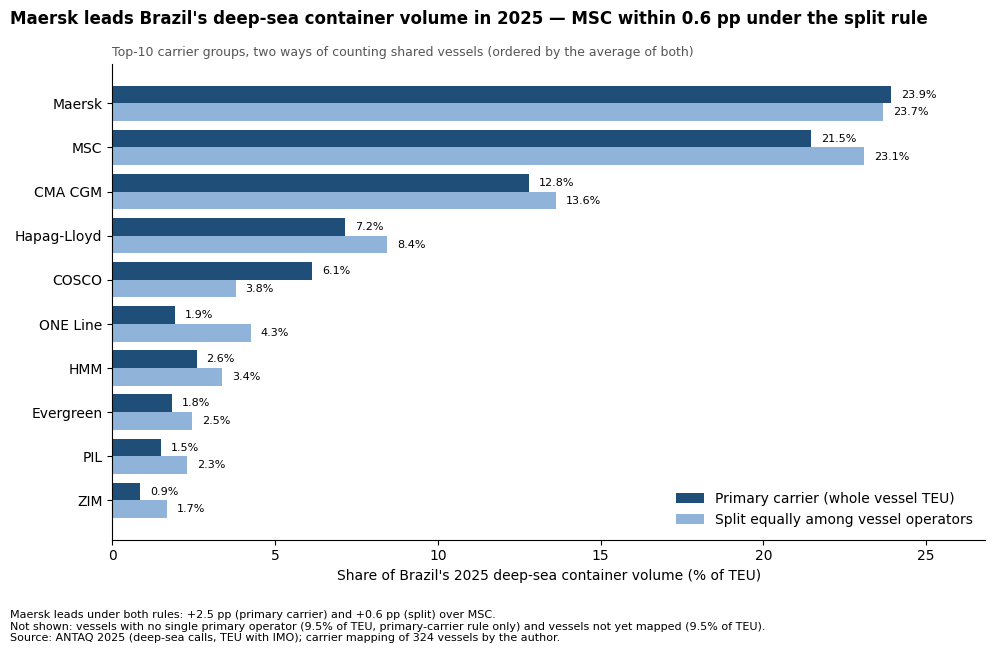

Gravado: outputs\figures\fig04_carrier_share.png


In [26]:
# Bloco 25 — Figura 4: quota de TEU de Longo Curso por grupo armador, nas duas regras (grava PNG, não mexe em dados)
import matplotlib.pyplot as plt

FIG = BASE / "outputs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

r4 = teu_por_grupo(tab)                                  # % do TEU LC total (Bloco 15)
top = r4.drop("Múltiplos", errors="ignore")
top = top.assign(media=top[["inteiro", "dividido"]].mean(axis=1)).sort_values("media", ascending=False).head(10)
mult = r4.loc["Múltiplos", "inteiro"] if "Múltiplos" in r4.index else 0
nao_map = 100 - r4["inteiro"].sum()
gap_i = r4.loc["Maersk", "inteiro"] - r4.loc["MSC", "inteiro"]
gap_d = r4.loc["Maersk", "dividido"] - r4.loc["MSC", "dividido"]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(top))
ax.barh(y - 0.2, top["inteiro"], height=0.4, color="#1f4e79", label="Primary carrier (whole vessel TEU)")
ax.barh(y + 0.2, top["dividido"], height=0.4, color="#8fb3d9", label="Split equally among vessel operators")
for i, (a, b) in enumerate(zip(top["inteiro"], top["dividido"])):
    ax.text(a + 0.3, i - 0.2, f"{a:.1f}%", va="center", fontsize=8)
    ax.text(b + 0.3, i + 0.2, f"{b:.1f}%", va="center", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(top.index)
ax.invert_yaxis()
ax.set_xlim(0, top[["inteiro", "dividido"]].max().max() * 1.12)
ax.set_xlabel("Share of Brazil's 2025 deep-sea container volume (% of TEU)")
fig.suptitle(f"Maersk leads Brazil's deep-sea container volume in 2025 — MSC within {gap_d:.1f} pp under the split rule",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
ax.set_title("Top-10 carrier groups, two ways of counting shared vessels (ordered by the average of both)",
             loc="left", fontsize=9, color="#555555")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

nota = (f"Maersk leads under both rules: +{gap_i:.1f} pp (primary carrier) and +{gap_d:.1f} pp (split) over MSC.\n"
        f"Not shown: vessels with no single primary operator ({mult:.1f}% of TEU, primary-carrier rule only) "
        f"and vessels not yet mapped ({nao_map:.1f}% of TEU).\n"
        f"Source: ANTAQ 2025 (deep-sea calls, TEU with IMO); carrier mapping of {len(tab)} vessels by the author.")
fig.text(0.01, -0.02, nota, fontsize=8, va="top")
fig.tight_layout()

out = FIG / "fig04_carrier_share.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gravado: {out.relative_to(BASE)}")

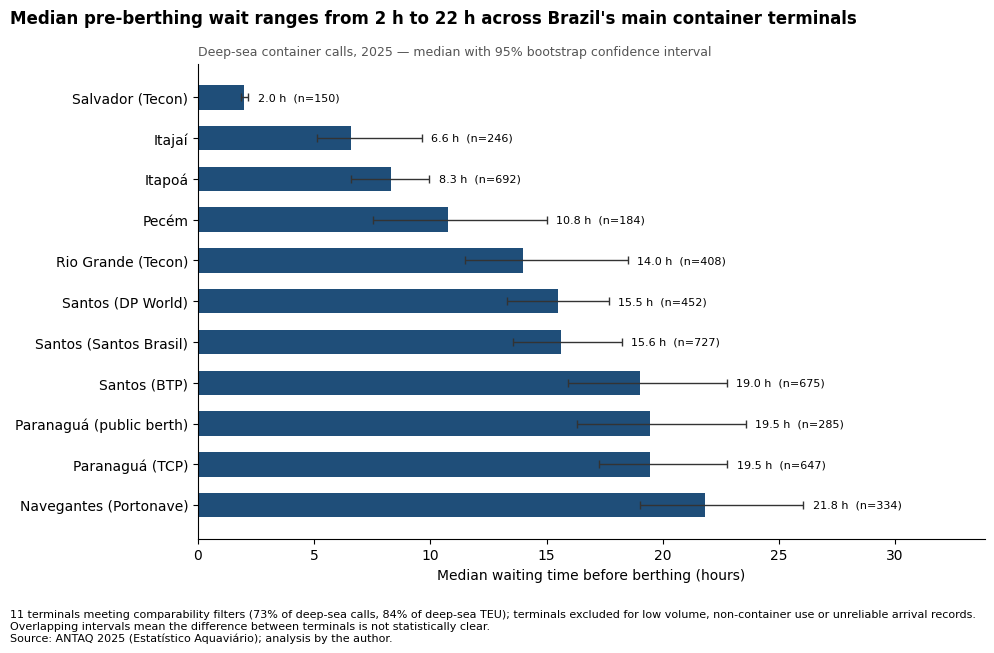

Gravado: outputs\figures\fig01_wait_by_terminal.png


In [27]:
# Bloco 26 — Figura 1: espera mediana antes de atracar por terminal, com IC 95% (grava PNG, não mexe em dados)
ROTULO_TERM = {
    "Salvador | Tecon Área 2": "Salvador (Tecon)",
    "Itajaí | Cais Arrendado Transitoriamente": "Itajaí",
    "Porto Itapoá Terminais Portuários": "Itapoá",
    "Terminal Portuário do Pecém": "Pecém",
    "Rio Grande | Cais Tecon Rio Grande S.A.": "Rio Grande (Tecon)",
    "DP World Santos": "Santos (DP World)",
    "Santos | Cais Da Santos Brasil (Ssz 16) - Privativo": "Santos (Santos Brasil)",
    "Santos | Cais Da Btp (Ssz 41) - Privativo": "Santos (BTP)",
    "Paranaguá | Cais Público": "Paranaguá (public berth)",
    "Paranaguá | Tcp": "Paranaguá (TCP)",
    "Portonave - Terminais Portuários de Navegantes": "Navegantes (Portonave)",
}

f1 = ic.join(final["escalas"]).sort_values("p50")              # ic (Bloco 10), final (Bloco 8)
rot1 = [ROTULO_TERM.get(t, t) for t in f1.index]
pct_esc = final["escalas"].sum() / len(esc_lc) * 100
pct_teu = final["teu_mil"].sum() / esc_lc["teu"].sum() * 1e5

fig, ax = plt.subplots(figsize=(10, 6))
y1 = np.arange(len(f1))
ax.barh(y1, f1["p50"], height=0.6, color="#1f4e79")
ax.errorbar(f1["p50"], y1, xerr=[f1["p50"] - f1["ic_inf"], f1["ic_sup"] - f1["p50"]],
            fmt="none", ecolor="#333333", capsize=3, lw=1)
for i, (p, sup, n) in enumerate(zip(f1["p50"], f1["ic_sup"], f1["escalas"])):
    ax.text(sup + 0.4, i, f"{p:.1f} h  (n={int(n)})", va="center", fontsize=8)
ax.set_yticks(y1)
ax.set_yticklabels(rot1)
ax.invert_yaxis()
ax.set_xlim(0, f1["ic_sup"].max() * 1.3)
ax.set_xlabel("Median waiting time before berthing (hours)")
fig.suptitle(f"Median pre-berthing wait ranges from {f1['p50'].min():.0f} h to {f1['p50'].max():.0f} h "
             f"across Brazil's main container terminals", x=0.01, ha="left", fontweight="bold", fontsize=12)
ax.set_title("Deep-sea container calls, 2025 — median with 95% bootstrap confidence interval",
             loc="left", fontsize=9, color="#555555")
ax.spines[["top", "right"]].set_visible(False)

nota = (f"{len(f1)} terminals meeting comparability filters ({pct_esc:.0f}% of deep-sea calls, {pct_teu:.0f}% of deep-sea TEU); "
        "terminals excluded for low volume, non-container use or unreliable arrival records.\n"
        "Overlapping intervals mean the difference between terminals is not statistically clear.\n"
        "Source: ANTAQ 2025 (Estatístico Aquaviário); analysis by the author.")
fig.text(0.01, -0.02, nota, fontsize=8, va="top")
fig.tight_layout()

out = FIG / "fig01_wait_by_terminal.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gravado: {out.relative_to(BASE)}")

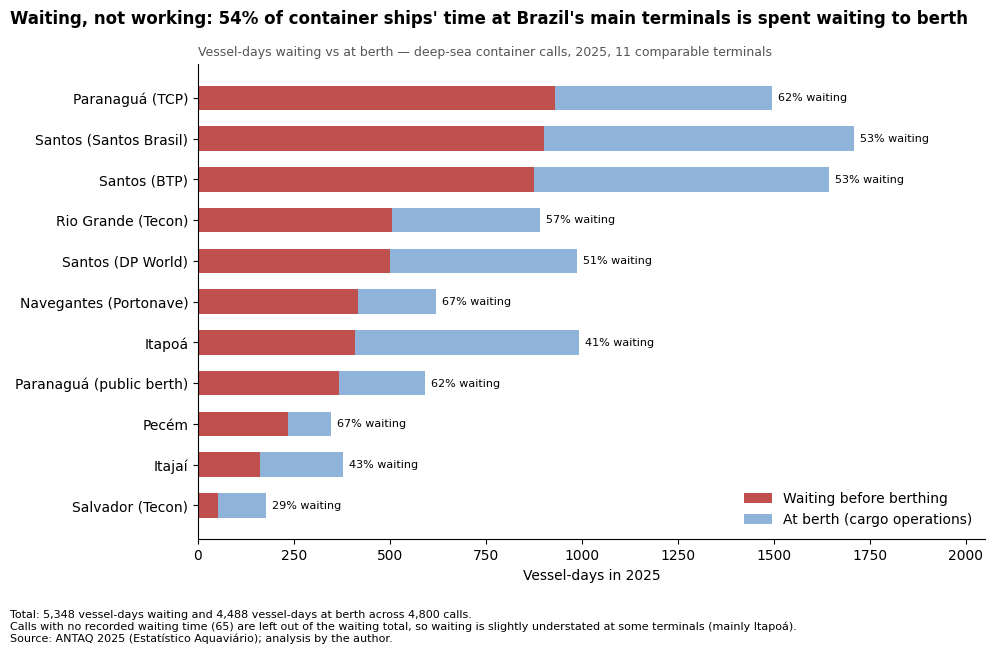

Gravado: outputs\figures\fig02_vessel_days.png


In [28]:
# Bloco 27 — Figura 2: navio-dias à espera vs no cais, por terminal (grava PNG, não mexe em dados)
f2 = nd.sort_values("dias_espera", ascending=True)               # nd (Bloco 16); maior em cima
rot2 = [ROTULO_TERM.get(t, t) for t in f2.index]
tot_e, tot_c = nd["dias_espera"].sum(), nd["dias_cais"].sum()
pct_tot = tot_e / (tot_e + tot_c) * 100

fig, ax = plt.subplots(figsize=(10, 6))
y2 = np.arange(len(f2))
ax.barh(y2, f2["dias_espera"], height=0.6, color="#c0504d", label="Waiting before berthing")
ax.barh(y2, f2["dias_cais"], height=0.6, left=f2["dias_espera"], color="#8fb3d9", label="At berth (cargo operations)")
for i, (e, c, p) in enumerate(zip(f2["dias_espera"], f2["dias_cais"], f2["pct_espera_no_total"])):
    ax.text(e + c + 15, i, f"{p:.0f}% waiting", va="center", fontsize=8)
ax.set_yticks(y2)
ax.set_yticklabels(rot2)
ax.set_xlim(0, (f2["dias_espera"] + f2["dias_cais"]).max() * 1.2)
ax.set_xlabel("Vessel-days in 2025")
fig.suptitle(f"Waiting, not working: {pct_tot:.0f}% of container ships' time at Brazil's main terminals is spent waiting to berth",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
ax.set_title("Vessel-days waiting vs at berth — deep-sea container calls, 2025, 11 comparable terminals",
             loc="left", fontsize=9, color="#555555")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

nota = (f"Total: {tot_e:,.0f} vessel-days waiting and {tot_c:,.0f} vessel-days at berth across {int(nd['escalas'].sum()):,} calls.\n"
        f"Calls with no recorded waiting time ({int(nd['escalas_sem_espera'].sum())}) are left out of the waiting total, "
        "so waiting is slightly understated at some terminals (mainly Itapoá).\n"
        "Source: ANTAQ 2025 (Estatístico Aquaviário); analysis by the author.")
fig.text(0.01, -0.02, nota, fontsize=8, va="top")
fig.tight_layout()

out = FIG / "fig02_vessel_days.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gravado: {out.relative_to(BASE)}")

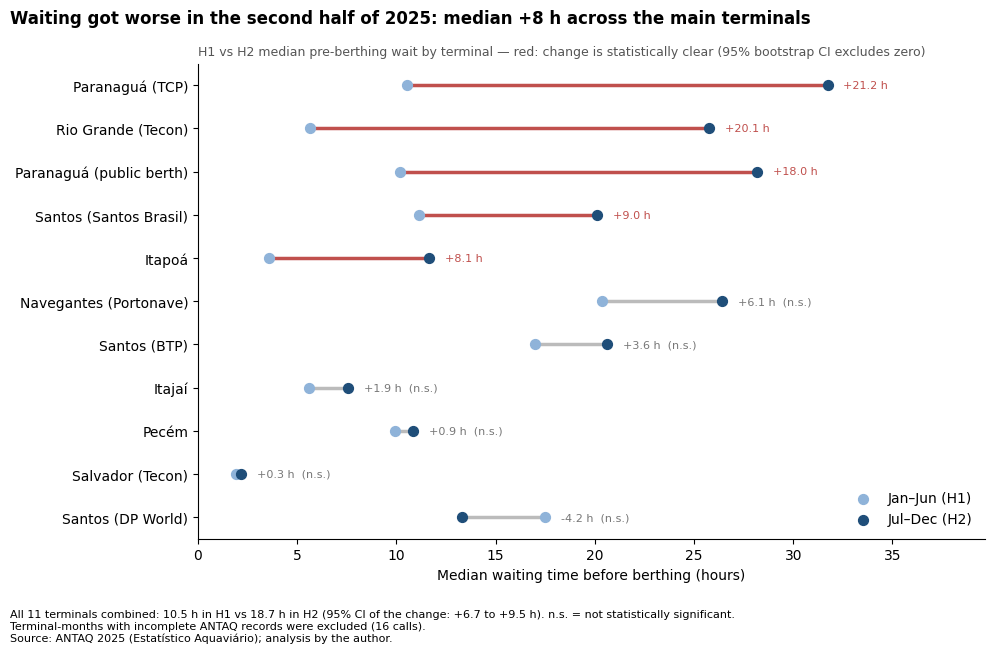

Gravado: outputs\figures\fig03_wait_h1_vs_h2.png


In [29]:
# Bloco 28 — Figura 3: espera 1.º vs 2.º semestre por terminal, com significância (grava PNG, não mexe em dados)
f3 = sem_term.sort_values("dif_h", ascending=True)                 # sem_term (Bloco 18); maior subida em cima
rot3 = [ROTULO_TERM.get(t, t) for t in f3.index]
sig3 = (f3["ic_inf"] > 0) | (f3["ic_sup"] < 0)
tot3 = sem_reg.loc["Total"]                                         # sem_reg (Bloco 18)

fig, ax = plt.subplots(figsize=(10, 6))
y3 = np.arange(len(f3))
for i, (a, b, s_) in enumerate(zip(f3["S1"], f3["S2"], sig3)):
    ax.plot([a, b], [i, i], color="#c0504d" if s_ else "#bbbbbb", lw=2.5, zorder=1)
ax.scatter(f3["S1"], y3, color="#8fb3d9", s=50, zorder=2, label="Jan–Jun (H1)")
ax.scatter(f3["S2"], y3, color="#1f4e79", s=50, zorder=3, label="Jul–Dec (H2)")
for i, (a, b, d, s_) in enumerate(zip(f3["S1"], f3["S2"], f3["dif_h"], sig3)):
    ax.text(max(a, b) + 0.8, i, f"{d:+.1f} h" + ("" if s_ else "  (n.s.)"), va="center", fontsize=8,
            color="#c0504d" if s_ else "#777777")
ax.set_yticks(y3)
ax.set_yticklabels(rot3)
ax.set_xlim(0, f3[["S1", "S2"]].max().max() * 1.25)
ax.set_xlabel("Median waiting time before berthing (hours)")
fig.suptitle(f"Waiting got worse in the second half of 2025: median +{tot3['dif_h']:.0f} h across the main terminals",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
ax.set_title("H1 vs H2 median pre-berthing wait by terminal — red: change is statistically clear "
             "(95% bootstrap CI excludes zero)", loc="left", fontsize=9, color="#555555")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

nota = (f"All {len(f3)} terminals combined: {tot3['S1']:.1f} h in H1 vs {tot3['S2']:.1f} h in H2 "
        f"(95% CI of the change: {tot3['ic_inf']:+.1f} to {tot3['ic_sup']:+.1f} h). n.s. = not statistically significant.\n"
        "Terminal-months with incomplete ANTAQ records were excluded (16 calls).\n"
        "Source: ANTAQ 2025 (Estatístico Aquaviário); analysis by the author.")
fig.text(0.01, -0.02, nota, fontsize=8, va="top")
fig.tight_layout()

out = FIG / "fig03_wait_h1_vs_h2.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gravado: {out.relative_to(BASE)}")

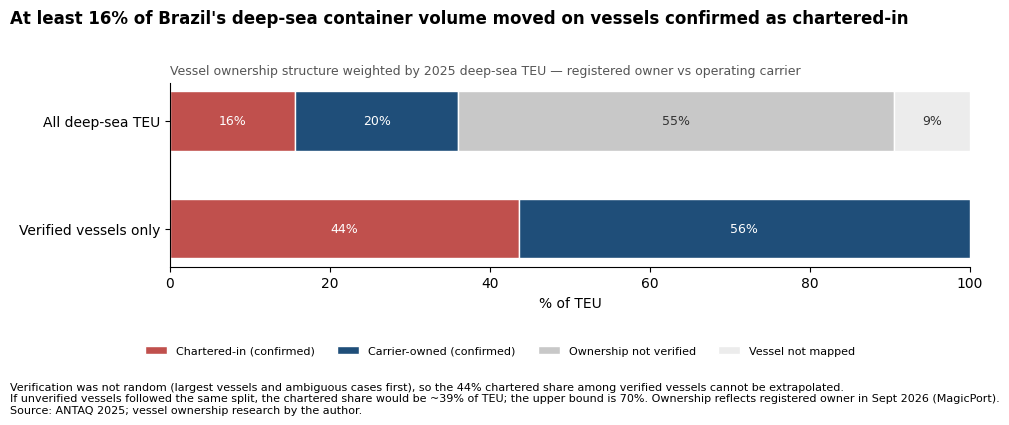

Gravado: outputs\figures\fig05_ownership.png


In [30]:
# Bloco 29 — Figura 5: TEU por estrutura de titularidade do navio (grava PNG, não mexe em dados)
t5 = tab.assign(teu_lc=pd.to_numeric(tab["IMO"], errors="coerce").astype("int64").map(teu_imo).fillna(0))
conf5 = t5["Titularidade_Confirmada"] == True
afr5 = t5.loc[conf5 & (t5["Estrutura_Titularidade"] == "Afretada"), "teu_lc"].sum()
pro5 = t5.loc[conf5 & (t5["Estrutura_Titularidade"] == "Propria"), "teu_lc"].sum()
nv5 = t5.loc[~conf5, "teu_lc"].sum()
nm5 = total - (afr5 + pro5 + nv5)                                   # total (Bloco 12)
p_ver = afr5 / (afr5 + pro5)

linha_all = pd.Series({"Chartered-in (confirmed)": afr5, "Carrier-owned (confirmed)": pro5,
                       "Ownership not verified": nv5, "Vessel not mapped": nm5}) / total * 100
linha_ver = pd.Series({"Chartered-in (confirmed)": afr5, "Carrier-owned (confirmed)": pro5}) / (afr5 + pro5) * 100
cores5 = {"Chartered-in (confirmed)": "#c0504d", "Carrier-owned (confirmed)": "#1f4e79",
          "Ownership not verified": "#c8c8c8", "Vessel not mapped": "#ececec"}

fig, ax = plt.subplots(figsize=(10, 4.6))
fig.subplots_adjust(left=0.17, right=0.97, top=0.82, bottom=0.42)   # posições fixas: gráfico, legenda e nota não se sobrepõem
for yy, serie in [(0, linha_all), (1, linha_ver)]:
    esq = 0
    for cat, v in serie.items():
        ax.barh(yy, v, left=esq, height=0.55, color=cores5[cat], edgecolor="white",
                label=cat if yy == 0 else None)
        if v >= 4:
            ax.text(esq + v / 2, yy, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                    color="white" if cat in ("Chartered-in (confirmed)", "Carrier-owned (confirmed)") else "#333333")
        esq += v
ax.set_yticks([0, 1])
ax.set_yticklabels(["All deep-sea TEU", "Verified vessels only"])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% of TEU")
fig.suptitle(f"At least {linha_all['Chartered-in (confirmed)']:.0f}% of Brazil's deep-sea container volume moved on vessels "
             f"confirmed as chartered-in", x=0.01, ha="left", fontweight="bold", fontsize=12)
ax.set_title("Vessel ownership structure weighted by 2025 deep-sea TEU — registered owner vs operating carrier",
             loc="left", fontsize=9, color="#555555")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.27), bbox_transform=fig.transFigure,
          ncol=4, frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

nota = (f"Verification was not random (largest vessels and ambiguous cases first), so the {p_ver:.0%} chartered share among "
        f"verified vessels cannot be extrapolated.\nIf unverified vessels followed the same split, the chartered share would be "
        f"~{(afr5 + p_ver * nv5) / total * 100:.0f}% of TEU; the upper bound is {(afr5 + nv5) / total * 100:.0f}%. "
        "Ownership reflects registered owner in Sept 2026 (MagicPort).\n"
        "Source: ANTAQ 2025; vessel ownership research by the author.")
fig.text(0.01, 0.17, nota, fontsize=8, va="top")

out = FIG / "fig05_ownership.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gravado: {out.relative_to(BASE)}")

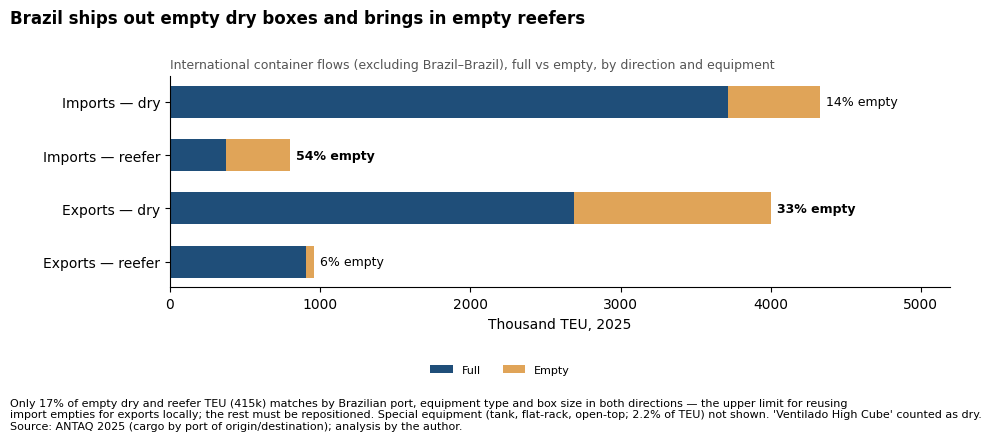

Gravado: outputs\figures\fig06_full_vs_empty.png


In [31]:
# Bloco 30 — Figura 6: cheio vs vazio por sentido e equipamento no comércio internacional (grava PNG, não mexe em dados)
ordem6 = [("entrada", "dry"), ("entrada", "reefer"), ("saida", "dry"), ("saida", "reefer")]
cv6 = intl.pivot_table(index=["sentido", "equip"], columns="box_status", values="teu",
                       aggfunc="sum", fill_value=0).loc[ordem6]              # intl (Bloco 20)
rot6 = ["Imports — dry", "Imports — reefer", "Exports — dry", "Exports — reefer"]
vz6 = intl[(intl["box_status"] == "Vazio") & (intl["equip"] != "especial")]
sobre6 = sobrepor(vz6, ["port_complex", "equip", "box_size"]).sum()        # sobrepor (Bloco 20)
pct_sobre6 = sobre6 / vz6["teu"].sum() * 100
pct_esp6 = intl.loc[intl["equip"] == "especial", "teu"].sum() / intl["teu"].sum() * 100
ch6, vzb6 = cv6["Cheio"] / 1e3, cv6["Vazio"] / 1e3

fig, ax = plt.subplots(figsize=(10, 4.8))
fig.subplots_adjust(left=0.17, right=0.95, top=0.84, bottom=0.40)
y6 = np.arange(len(cv6))
ax.barh(y6, ch6, height=0.6, color="#1f4e79", label="Full")
ax.barh(y6, vzb6, left=ch6, height=0.6, color="#e0a458", label="Empty")
for i, (c, v) in enumerate(zip(ch6, vzb6)):
    p = v / (c + v) * 100
    ax.text(c + v + 40, i, f"{p:.0f}% empty", va="center", fontsize=9, fontweight="bold" if p >= 30 else "normal")
ax.set_yticks(y6)
ax.set_yticklabels(rot6)
ax.invert_yaxis()
ax.set_xlim(0, (ch6 + vzb6).max() * 1.2)
ax.set_xlabel("Thousand TEU, 2025")
fig.suptitle("Brazil ships out empty dry boxes and brings in empty reefers",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
ax.set_title("International container flows (excluding Brazil–Brazil), full vs empty, by direction and equipment",
             loc="left", fontsize=9, color="#555555")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.26), bbox_transform=fig.transFigure,
          ncol=2, frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

nota = (f"Only {pct_sobre6:.0f}% of empty dry and reefer TEU ({sobre6 / 1e3:,.0f}k) matches by Brazilian port, equipment type and box size "
        "in both directions — the upper limit for reusing\nimport empties for exports locally; the rest must be repositioned. "
        f"Special equipment (tank, flat-rack, open-top; {pct_esp6:.1f}% of TEU) not shown. 'Ventilado High Cube' counted as dry.\n"
        "Source: ANTAQ 2025 (cargo by port of origin/destination); analysis by the author.")
fig.text(0.01, 0.17, nota, fontsize=8, va="top")

out = FIG / "fig06_full_vs_empty.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gravado: {out.relative_to(BASE)}")

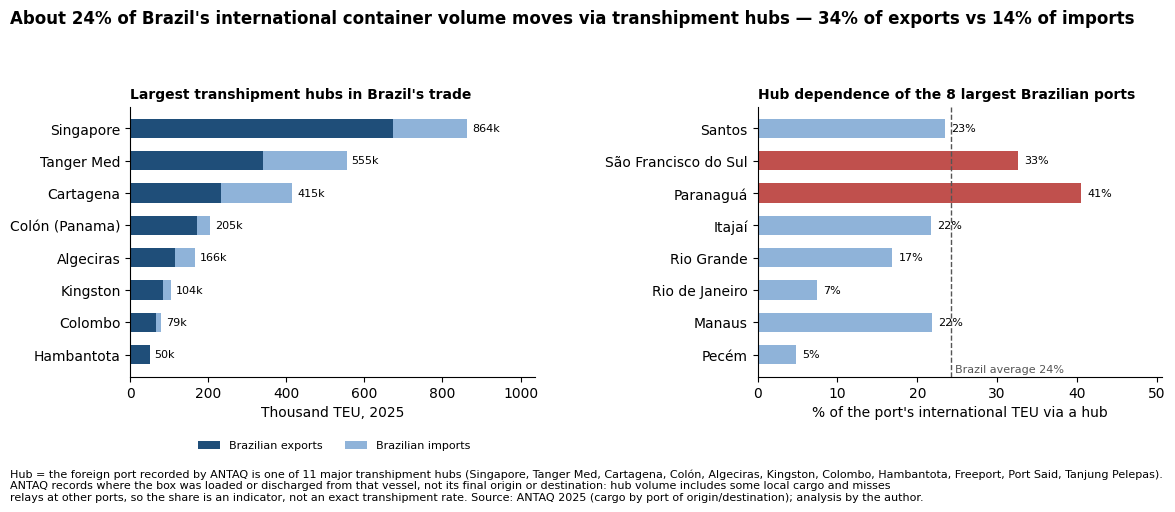

Gravado: outputs\figures\fig07_transhipment_hubs.png


In [32]:
# Bloco 31 — Figura 7: hubs de transbordo — maiores hubs e dependência por porto brasileiro (grava PNG, não mexe em dados)
tot7 = ext["teu"].sum()                                                    # ext (Blocos 22-23)
pct7 = ext.loc[ext["hub"], "teu"].sum() / tot7 * 100
pct7_s = {s: ext.loc[(ext["sentido"] == s) & ext["hub"], "teu"].sum() / ext.loc[ext["sentido"] == s, "teu"].sum() * 100
          for s in ["entrada", "saida"]}

hub7 = ext[ext["hub"]].pivot_table(index="porto_norm", columns="sentido", values="teu", aggfunc="sum", fill_value=0) / 1e3
hub7["total"] = hub7.sum(axis=1)
hub7 = hub7.sort_values("total", ascending=False).head(8)
ROT_HUB = {"Colón (Atlântico)": "Colón (Panama)"}

br7 = ext.pivot_table(index="port_complex", columns="hub", values="teu", aggfunc="sum", fill_value=0)
br7["teu_mil"] = br7.sum(axis=1) / 1e3
br7["pct"] = br7[True] / (br7[True] + br7[False]) * 100
br7 = br7.sort_values("teu_mil", ascending=False).head(8)
ROT_BR = {"Paranaguá - Antonina": "Paranaguá", "Rio de Janeiro -  Niterói": "Rio de Janeiro",
          "Pecém - Fortaleza": "Pecém", "Aratu - Salvador": "Salvador", "Suape - Recife": "Suape"}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5.4))
fig.subplots_adjust(left=0.11, right=0.97, top=0.80, bottom=0.30, wspace=0.55)

# Painel esquerdo — maiores hubs
yh = np.arange(len(hub7))
a1.barh(yh, hub7["saida"], height=0.6, color="#1f4e79", label="Brazilian exports")
a1.barh(yh, hub7["entrada"], left=hub7["saida"], height=0.6, color="#8fb3d9", label="Brazilian imports")
for i, t in enumerate(hub7["total"]):
    a1.text(t + 12, i, f"{t:,.0f}k", va="center", fontsize=8)
a1.set_yticks(yh)
a1.set_yticklabels([ROT_HUB.get(p, p) for p in hub7.index])
a1.invert_yaxis()
a1.set_xlim(0, hub7["total"].max() * 1.2)
a1.set_xlabel("Thousand TEU, 2025")
a1.set_title("Largest transhipment hubs in Brazil's trade", loc="left", fontsize=10, fontweight="bold")
a1.legend(loc="upper center", bbox_to_anchor=(0.28, 0.2), bbox_transform=fig.transFigure, ncol=2, frameon=False, fontsize=8)
a1.spines[["top", "right"]].set_visible(False)

# Painel direito — dependência por porto brasileiro
yb = np.arange(len(br7))
a2.barh(yb, br7["pct"], height=0.6, color=["#c0504d" if p > pct7 else "#8fb3d9" for p in br7["pct"]])
for i, p in enumerate(br7["pct"]):
    a2.text(p + 0.8, i, f"{p:.0f}%", va="center", fontsize=8)
a2.axvline(pct7, color="#555555", ls="--", lw=1)
a2.text(pct7 + 0.5, len(br7) - 0.4, f"Brazil average {pct7:.0f}%", fontsize=8, color="#555555", va="bottom")
a2.set_yticks(yb)
a2.set_yticklabels([ROT_BR.get(p, p) for p in br7.index])
a2.invert_yaxis()
a2.set_xlim(0, br7["pct"].max() * 1.25)
a2.set_xlabel("% of the port's international TEU via a hub")
a2.set_title("Hub dependence of the 8 largest Brazilian ports", loc="left", fontsize=10, fontweight="bold")
a2.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"About {pct7:.0f}% of Brazil's international container volume moves via transhipment hubs — "
             f"{pct7_s['saida']:.0f}% of exports vs {pct7_s['entrada']:.0f}% of imports",
             x=0.01, ha="left", fontweight="bold", fontsize=12)

nota = ("Hub = the foreign port recorded by ANTAQ is one of 11 major transhipment hubs (Singapore, Tanger Med, Cartagena, Colón, Algeciras, "
        "Kingston, Colombo, Hambantota, Freeport, Port Said, Tanjung Pelepas).\n"
        "ANTAQ records where the box was loaded or discharged from that vessel, not its final origin or destination: hub volume includes some "
        "local cargo and misses\nrelays at other ports, so the share is an indicator, not an exact transhipment rate. "
        "Source: ANTAQ 2025 (cargo by port of origin/destination); analysis by the author.")
fig.text(0.01, 0.13, nota, fontsize=8, va="top")

out = FIG / "fig07_transhipment_hubs.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gravado: {out.relative_to(BASE)}")

In [33]:
# Bloco 32 — Exportar a base de escalas para o notebook 04 (modelo de espera)
out = BASE / "data" / "processed" / "calls_2025.csv"
esc.to_csv(out, index=False)
print(out.relative_to(BASE), esc.shape)
print(esc.dtypes.to_string())

data\processed\calls_2025.csv (10007, 21)
call_id                        int64
year                           int64
month                          int64
terminal                      object
navigation                    object
imo                           object
teu                          float64
tonnes                       float64
t_stoppage_h                 float64
t_wait_h                     float64
t_to_ops_h                   float64
t_ops_h                      float64
t_to_unberth_h               float64
t_berth_h                    float64
t_stay_h                     float64
t_wait_h_discrepant             bool
t_to_ops_h_discrepant           bool
t_ops_h_discrepant              bool
t_to_unberth_h_discrepant       bool
t_berth_h_discrepant            bool
t_stay_h_discrepant             bool
